<a href="https://colab.research.google.com/github/AellaSahithi/rainfall_prediction_model/blob/main/rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pickle


Data Collection & Processing

In [ ]:
data=pd.read_csv('/content/Rainfall.csv')

In [ ]:
data.shape

(366, 12)

In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
data.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [ ]:
data.head()


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
data.value_counts('rainfall')

,count
rainfall,
yes,249
no,117


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [ ]:
data.value_counts('day')

,count
day,
1,12
2,12
3,12
4,12
5,12
6,12
7,12
8,12
9,12


In [ ]:
data['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
data.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [ ]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

Removing extra white spaces

In [ ]:
data.columns=data.columns.str.strip()

In [ ]:
data.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [ ]:
data=data.drop(columns=['day'])

In [ ]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
data['winddirection']=data['winddirection'].fillna(data['winddirection'].mode()[0])
data['windspeed']=data['windspeed'].fillna(data['windspeed'].median())

In [ ]:
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


Data Encoding

In [ ]:
data['rainfall']=data['rainfall'].map({'yes':1,'no':0})

In [ ]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


Exploratory Data Analysis

In [ ]:
data.shape

(366, 11)

In [ ]:
sns.set(style='whitegrid')

In [ ]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


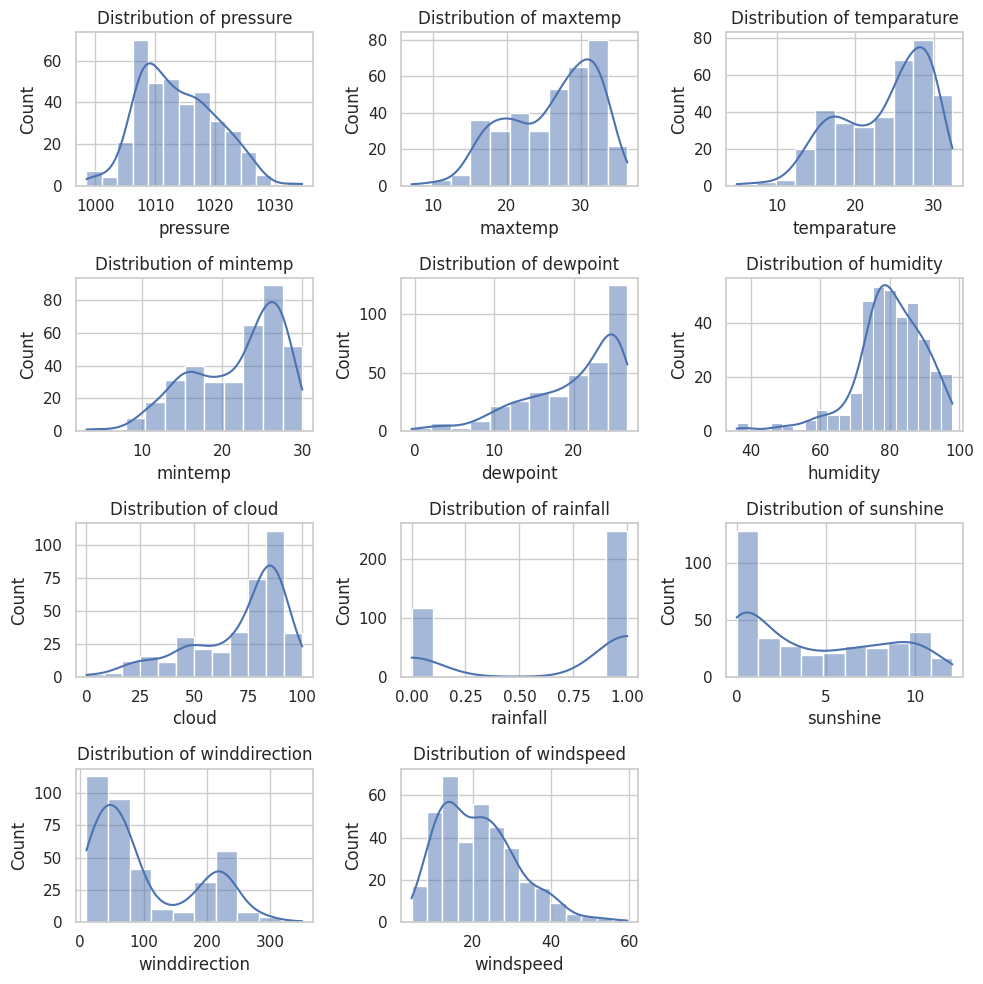

In [ ]:
plt.figure(figsize=(10,10))

for i, column in enumerate(['pressure','maxtemp', 'temparature', 'mintemp', 'dewpoint','humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection','windspeed'],1):
  plt.subplot(4,3,i)
  sns.histplot(data[column],kde=True)
  plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

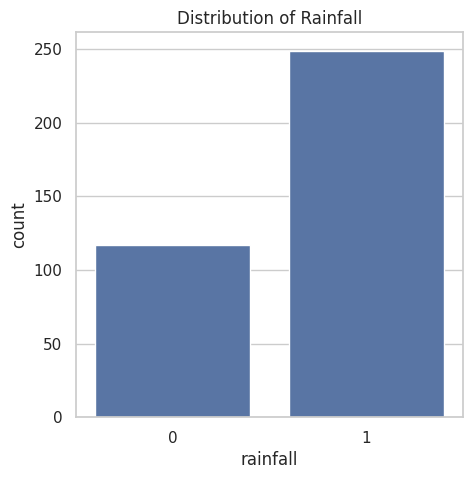

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='rainfall',data=data)
plt.title('Distribution of Rainfall')
plt.show()

Correlation Matrix

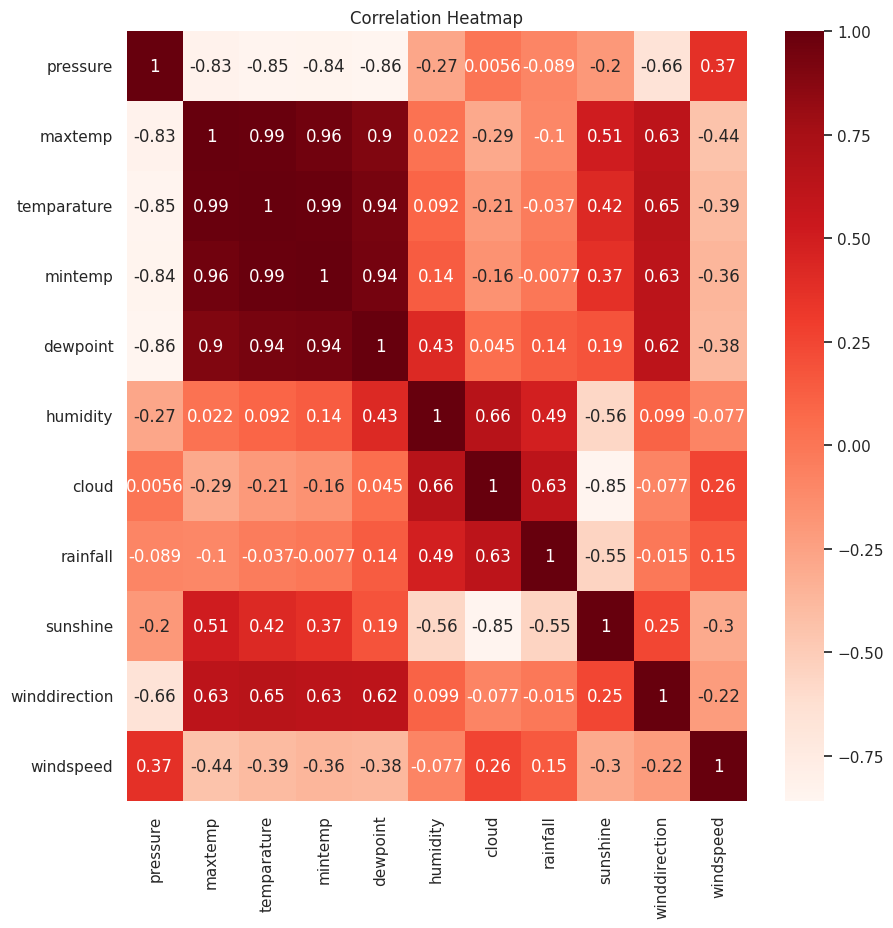

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True,cmap='Reds')
plt.title("Correlation Heatmap")
plt.show()

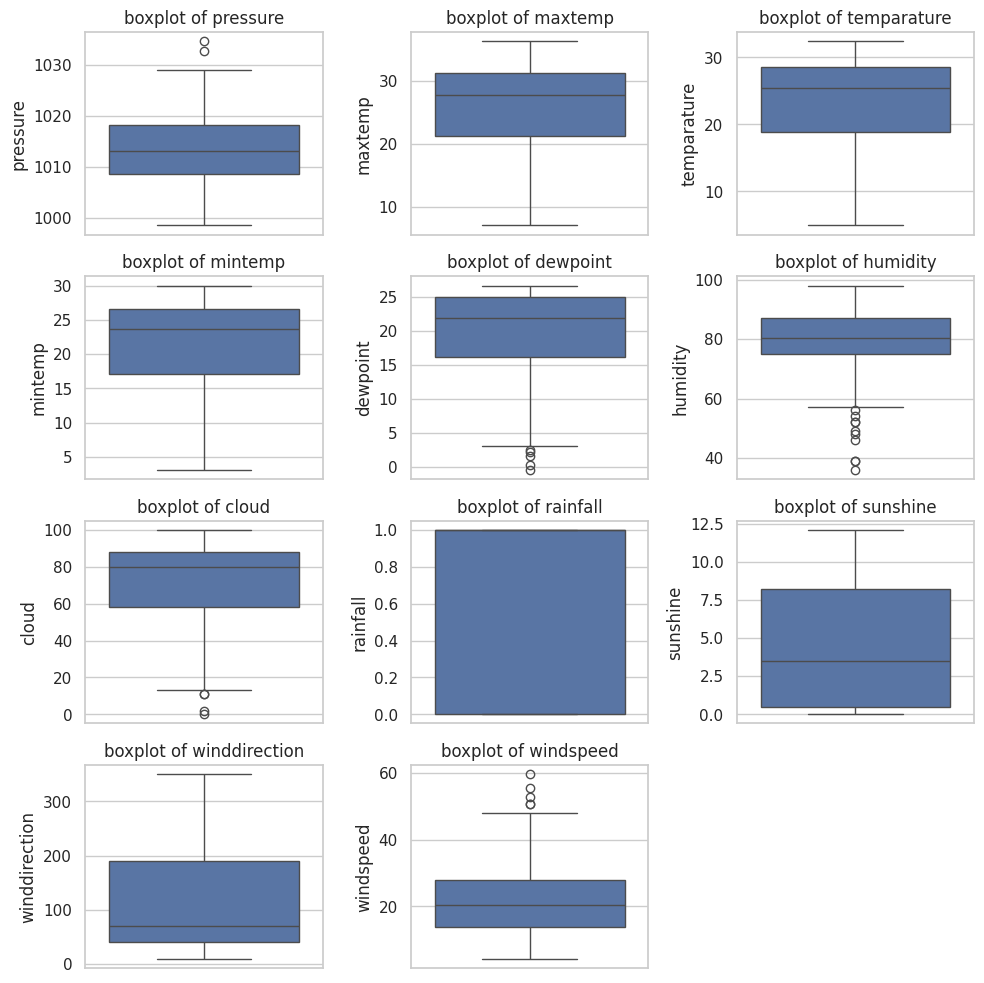

In [ ]:
plt.figure(figsize=(10,10))

for i, column in enumerate(['pressure','maxtemp', 'temparature', 'mintemp', 'dewpoint','humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection','windspeed'],1):
  plt.subplot(4,3,i)
  sns.boxplot(data[column])
  plt.title(f'boxplot of {column}')
plt.tight_layout()
plt.show()

Data Preprocessing

In [ ]:
data=data.drop(columns=['mintemp','maxtemp','temparature'])

In [ ]:
data.shape

(366, 8)

In [ ]:
data.value_counts('rainfall')

,count
rainfall,
1,249
0,117


In [ ]:
#seperating majority and minority classes
df_major=data[data['rainfall']==1]
df_minor=data[data['rainfall']==0]

In [ ]:
df_major.shape

(249, 8)

In [ ]:
df_minor.shape

(117, 8)

In [ ]:
#using resampling to down sample the majority to minority sample count
df_maj_downsample=resample(df_major,replace=False,n_samples=len(df_minor),random_state=42)

In [ ]:
df_maj_downsample.shape

(117, 8)

In [ ]:
df_downsampled=pd.concat([df_maj_downsample,df_minor])

In [ ]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [ ]:
df_downsampled.tail()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
351,1025.9,-0.4,39,25,0,9.1,20.0,35.6
352,1026.4,3.1,48,11,0,9.5,40.0,25.2
353,1025.4,8.7,62,71,0,2.1,30.0,29.0
360,1020.6,13.3,74,87,0,0.6,30.0,21.6
365,1026.4,13.0,74,66,0,5.7,20.0,23.3


In [ ]:
df_downsampled=df_downsampled.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


Splitting features and Targets

In [ ]:
x=df_downsampled.drop(columns='rainfall',axis=1)
y=df_downsampled['rainfall']

In [ ]:
print(x)
print('*********************************************')
print(y)

     pressure  dewpoint  humidity  cloud  sunshine  winddirection  windspeed
0      1022.2      14.1        78     90       0.0           30.0       28.5
1      1013.4      19.5        69     17      10.5           70.0       12.4
2      1006.1      24.4        74     27      10.8          220.0        8.7
3      1007.6      24.8        85     84       1.8           70.0       34.8
4      1021.2       8.4        66     18      10.1           20.0       24.4
..        ...       ...       ...    ...       ...            ...        ...
229    1008.1      25.4        86     75       5.7           20.0        9.5
230    1010.1      19.9        91     89       0.0           70.0       31.8
231    1020.6      14.7        91     88       0.3           50.0       24.4
232    1008.3      24.1        74     29       5.7           10.0        4.4
233    1005.0      26.1        87     82       2.2          160.0       12.6

[234 rows x 7 columns]
*********************************************
0     

Splitting Training and Testing data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(234, 7) (187, 7) (47, 7)


In [ ]:
print(y.shape,y_test.shape,y_test.shape)

(234,) (47,) (47,)


In [ ]:
rf_model=RandomForestClassifier(random_state=42)
param_grid_rf={
    'n_estimators':[50,100,150],
    'max_features':['sqrt','log2'],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [ ]:
#Hypertuning using gridsearchCV
grid_search_rf=GridSearchCV(estimator=rf_model,param_grid=param_grid_rf,cv=5,n_jobs=-1,verbose=2)
grid_search_rf.fit(x_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             verbose=2)

In [ ]:
best_rf_model=grid_search_rf.best_estimator_
print("best parameters for Random Forest:",grid_search_rf.best_params_)

best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


Model Evaluation

In [ ]:
cv_scores=cross_val_score(best_rf_model,x_train,y_train,cv=5)
print('Cross validation score:',cv_scores)
print('Mean cross validation score:',np.mean(cv_scores))

Cross validation score: [0.78947368 0.73684211 0.86486486 0.75675676 0.81081081]
Mean cross validation score: 0.7917496443812234


In [ ]:
y_pred=best_rf_model.predict(x_test)
print('Confusion Matrix:',confusion_matrix(y_test,y_pred))
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Classification report',classification_report(y_test,y_pred))

Confusion Matrix: [[20  4]
 [ 5 18]]
Accuracy: 0.8085106382978723
Classification report               precision    recall  f1-score   support

           0       0.80      0.83      0.82        24
           1       0.82      0.78      0.80        23

    accuracy                           0.81        47
   macro avg       0.81      0.81      0.81        47
weighted avg       0.81      0.81      0.81        47



Prediction on Unknown data

In [ ]:
input=(1278.8,17.8,78,87,17.1,27.1,82.1)
input_df=pd.DataFrame([input],columns=['pressure','dewpoint',' humidity','cloud','sunshine',' winddirection','windspeed'])

In [ ]:
input_df.rename(columns={' winddirection':'winddirection',
                         ' humidity':'humidity'}, inplace=True)


In [ ]:
input_df

,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1278.8,17.8,78,87,17.1,27.1,82.1


In [ ]:
prediction=best_rf_model.predict(input_df)


In [ ]:
print('Prediction :' ,'Rainfall' if prediction[0]==1 else 'NO Rainfall')

Prediction : NO Rainfall


Pickle File

In [ ]:
model_data={'model':best_rf_model,"feature_names":x.columns.tolist()}
with open('rainfall_prediction_model.pkl','wb') as file:
  pickle.dump(model_data,file)

In [ ]:
import pickle
import pandas as pd


In [ ]:
with open('rainfall_prediction_model.pkl','rb') as file:
  model_data=pickle.load(file)

In [ ]:
model=model_data['model']
feature_names=model_data['feature_names']

In [ ]:
input=(1422.4,20.1,80,90,17.5,29.0,81.2)
input_df=pd.DataFrame([input],columns=feature_names)

In [ ]:
prediction=best_rf_model.predict(input_df)
print('Prediction :' ,'Rainfall' if prediction[0]==1 else 'NO Rainfall')

Prediction : Rainfall
